# Bibliotecas

In [227]:
import pandas as pd
import numpy as np
from itertools import combinations
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.compose import make_column_selector as selector

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Funções e Transformadores customizados

In [228]:
def substituir_valores_coluna(
    df: pd.DataFrame,
    coluna: str,
    mapeamento: dict,
    converter_numerico: bool = True
) -> pd.DataFrame:
    """
    Substitui valores específicos de uma coluna usando um dicionário.

    Parâmetros
    ----------
    df : DataFrame
        DataFrame original
    coluna : str
        Nome da coluna a ser tratada
    mapeamento : dict
        Ex: {'baixo': 1, 'medio': 2, 'alto': 3}
    converter_numerico : bool
        Se True, tenta converter a coluna para numérico no final

    Retorno
    -------
    DataFrame com a coluna corrigida
    """

    df = df.copy()

    # Substitui apenas os valores especificados
    df[coluna] = df[coluna].replace(mapeamento)

    if converter_numerico:
        df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

    return df

In [229]:
# Para testar as combinações de feature essa função criar as combinações possíveis
def gerar_combinacoes_features(features, max_features=4):
    combinacoes = []
    for k in range(1, max_features + 1):
        combinacoes.extend(list(combinations(features, k)))
    return combinacoes

In [230]:
# Seleciona apenas as fetures necessárias e evita erros
class FeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, features=None):
        self.features = features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[list(self.features)]

# 1 Importação da base e ajustes

In [231]:
arquivo = r"https://raw.githubusercontent.com/vbomura/tc5/03b05a676fa48320170229c8be9c7a22fe5c0f7f/Codigos/base_anos_limpo.xlsx"

df = pd.read_excel(arquivo)

## Corrigindo valores das colunas

In [232]:
# Corrigindo valores das fases
mapeamento_defasagem = {
    'ALFA': 0,
    'FASE 1': 1,
    'FASE 2': 2,
    'FASE 3': 3,
    'FASE 4': 4,
    'FASE 5': 5,
    'FASE 6': 6 
}

df = substituir_valores_coluna(
    df=df,
    coluna='fase',
    mapeamento=mapeamento_defasagem
)

## Separando os alunos que ficaram mais de um ano no programa

In [233]:
# Separando alunos que ficarão mais de um ano no programa
alunos_repetidos = (
    df
    .groupby('ra')
    .size()
    .reset_index(name='qtd_registros')
)

alunos_repetidos = alunos_repetidos[
    alunos_repetidos['qtd_registros'] > 1
]

In [234]:
# Criando o dataframe e também já ordenando ele
df_repetidos = df[
    df['ra'].isin(alunos_repetidos['ra'])
].copy()

df_repetidos = df_repetidos.sort_values(
    by=['ra', 'ano_aba']
)

In [235]:
# criamos uma coluna com a defasagem do ano seguinte
df_repetidos['defasagem_proximo_ano'] = (
    df.groupby('ra')['defasagem']
      .shift(-1)
)

# Aqui iremos indicar qual o movimento que a defasagem do aluno teve
condicoes = [
    df_repetidos['defasagem_proximo_ano'] < df_repetidos['defasagem'],
    df_repetidos['defasagem_proximo_ano'] == df_repetidos['defasagem'],
    df_repetidos['defasagem_proximo_ano'] > df_repetidos['defasagem']
]

valores = [-1, 0, 1]

df_repetidos['movimento_proximo_ano'] = np.select(
    condicoes,
    valores,
    default=np.nan
)

In [236]:
df_modelo = df_repetidos.dropna(
    subset=['defasagem_proximo_ano', 'movimento_proximo_ano']
).copy()

### Criando uma coluna que tem menos ruído

In [237]:
condicoes = [
    df_modelo['defasagem_proximo_ano'].isin([-4, -3]),
    df_modelo['defasagem_proximo_ano'] == 2
]

valores = [
    -2,
    1
]

df_modelo['defasagem_proximo_ano_sem_ruido'] = np.select(
    condicoes,
    valores,
    default=df_modelo['defasagem_proximo_ano']
)

# 2 Pipeline do algoritmo

## Variaves e ajustes de pré-processamento

In [238]:
# Separando as features e target
# target = 'defasagem_proximo_ano'
target = 'movimento_proximo_ano'
# target = 'defasagem_proximo_ano_sem_ruido'

features = [
            # 'ra',
            # 'genero', 
            'inde', 
            # 'iaa', 
            # 'ieg', 
            # 'ips', 
            'ida', 
            # 'mat', 
            # 'por', 
            'ipv', 
            # 'ian', 
            'defasagem',
            # 'ipp',
            # 'instituicao_de_ensino', 
            # 'pedra', 
            # 'fase'
            ]

In [239]:
feature_sets = gerar_combinacoes_features(features, max_features=4)

In [240]:
# Criamos um preprocessador para evitar erros na seleção de colunas, ele é dinâmico

preprocessador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), selector(dtype_include='number')),
        ('cat', OneHotEncoder(handle_unknown='ignore'), selector(dtype_include='object'))
    ]
)

## Criando os pipelines

In [241]:
# Regressão logística
pipe_log = Pipeline(steps=[
    ('selector', FeatureSelector()),
    ('preprocessador', preprocessador),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        multi_class='ovr',
        random_state=42
    ))
])

# Random forest
pipe_rf = Pipeline(steps=[
    ('selector', FeatureSelector()),
    ('preprocessador', preprocessador),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])


In [242]:
# Aplica as configurações de várias features
param_grid_log = {
    'selector__features': feature_sets
}

param_grid_rf = {
    'selector__features': feature_sets
}

## Treinando os modelos

In [243]:
X = df_modelo[features]
y = df_modelo[target]

In [244]:
grid_log = GridSearchCV(
    estimator=pipe_log,
    param_grid=param_grid_log,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_log.fit(X, y)


grid_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X, y)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\bryan\anaconda3\envs\fase4\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'selector__features': [('inde',), ('ida',), ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,features,"('ida', ...)"


## Resultados

In [245]:
# Melhor resultado Regressão logística
print('Melhor resultado Regressão logística')
print("Melhor score:", grid_log.best_score_)
print("Melhores parâmetros:", grid_log.best_params_)

print('')
print('Melhor resultado Random forest')
# Melhor resultado Random forest
print("Melhor score:", grid_rf.best_score_)
print("Melhores parâmetros:", grid_rf.best_params_)


Melhor resultado Regressão logística
Melhor score: 0.4575103715416756
Melhores parâmetros: {'selector__features': ('inde', 'ipv', 'defasagem')}

Melhor resultado Random forest
Melhor score: 0.4770411238911586
Melhores parâmetros: {'selector__features': ('ida', 'ipv', 'defasagem')}


### Melhores resultados

In [246]:
resultados = pd.DataFrame(grid_log.cv_results_)

ranking_log = (
    resultados[
        ['mean_test_score', 'std_test_score', 'param_selector__features']
    ]
    .sort_values('mean_test_score', ascending=False)
)

ranking_log.head(10)

,mean_test_score,std_test_score,param_selector__features
12,0.457510,0.039292,"(inde, ipv, defasagem)"
14,0.453909,0.034526,"(inde, ida, ipv, defasagem)"
9,0.452803,0.043183,"(ipv, defasagem)"
13,0.452779,0.036429,"(ida, ipv, defasagem)"
6,0.442187,0.042379,"(inde, defasagem)"
8,0.426741,0.055287,"(ida, defasagem)"
11,0.422582,0.037869,"(inde, ida, defasagem)"
10,0.403943,0.025279,"(inde, ida, ipv)"
5,0.376952,0.026847,"(inde, ipv)"
2,0.366326,0.025709,"(ipv,)"


In [247]:
resultados = pd.DataFrame(grid_rf.cv_results_)

ranking_rf = (
    resultados[
        ['mean_test_score', 'std_test_score', 'param_selector__features']
    ]
    .sort_values('mean_test_score', ascending=False)
)

ranking_rf.head(10)

,mean_test_score,std_test_score,param_selector__features
13,0.477041,0.026065,"(ida, ipv, defasagem)"
12,0.459824,0.013940,"(inde, ipv, defasagem)"
14,0.451738,0.041602,"(inde, ida, ipv, defasagem)"
11,0.450275,0.022546,"(inde, ida, defasagem)"
9,0.445255,0.036596,"(ipv, defasagem)"
8,0.421019,0.007376,"(ida, defasagem)"
6,0.408805,0.036530,"(inde, defasagem)"
7,0.384632,0.021538,"(ida, ipv)"
5,0.377875,0.016154,"(inde, ipv)"
4,0.375086,0.042114,"(inde, ida)"


### Avaliação fora do Grid (holdout real)

In [248]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

best_model_log = grid_log.best_estimator_
best_model_log.fit(X_train, y_train)


c:\Users\bryan\anaconda3\envs\fase4\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('selector', ...), ('preprocessador', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,features,"('inde', ...)"
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [249]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

best_model_rf = grid_rf.best_estimator_
best_model_rf.fit(X_train, y_train)


,steps,"[('selector', ...), ('preprocessador', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,features,"('ida', ...)"
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


### Metricas essencias

In [250]:
y_pred = best_model_log.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.35      0.58      0.43        45
         0.0       0.56      0.26      0.36       115
         1.0       0.55      0.74      0.63        92

    accuracy                           0.49       252
   macro avg       0.49      0.53      0.47       252
weighted avg       0.52      0.49      0.47       252



In [251]:
y_pred = best_model_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.37      0.29      0.33        45
         0.0       0.49      0.49      0.49       115
         1.0       0.51      0.57      0.54        92

    accuracy                           0.48       252
   macro avg       0.46      0.45      0.45       252
weighted avg       0.47      0.48      0.48       252



### Matriz de confusão

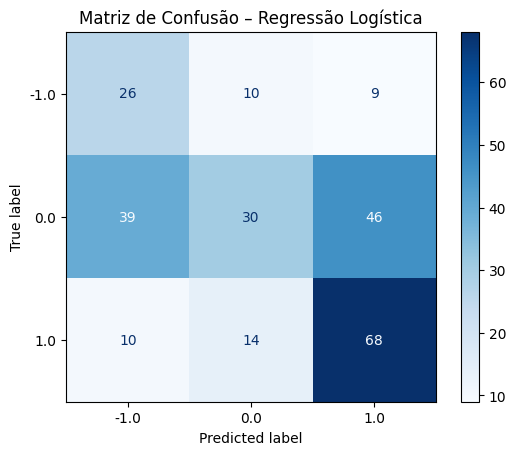

In [252]:
ConfusionMatrixDisplay.from_estimator(
    best_model_log,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Matriz de Confusão – Regressão Logística")
plt.show()

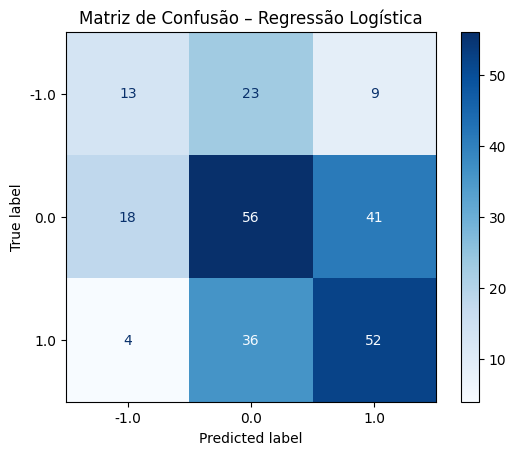

In [253]:
ConfusionMatrixDisplay.from_estimator(
    best_model_rf,
    X_test,
    y_test,
    cmap='Blues'
)

plt.title("Matriz de Confusão – Regressão Logística")
plt.show()